Running chains for distribution plot...
Done.
Running chains for convergence plot...
Done.

TV distance for distribution plot, N=2:
  Oracle MH   : 2.351131e-02
  Pref-MH     : 3.500166e-02
  Plug-in MH  : 3.724740e-01

Acceptance rates:
  Oracle MH   : 0.6309
  N=1   | Pref-MH: 0.2204 | Plug-in: 0.2610
  N=2   | Pref-MH: 0.3004 | Plug-in: 0.3900
  N=4   | Pref-MH: 0.3898 | Plug-in: 0.4872


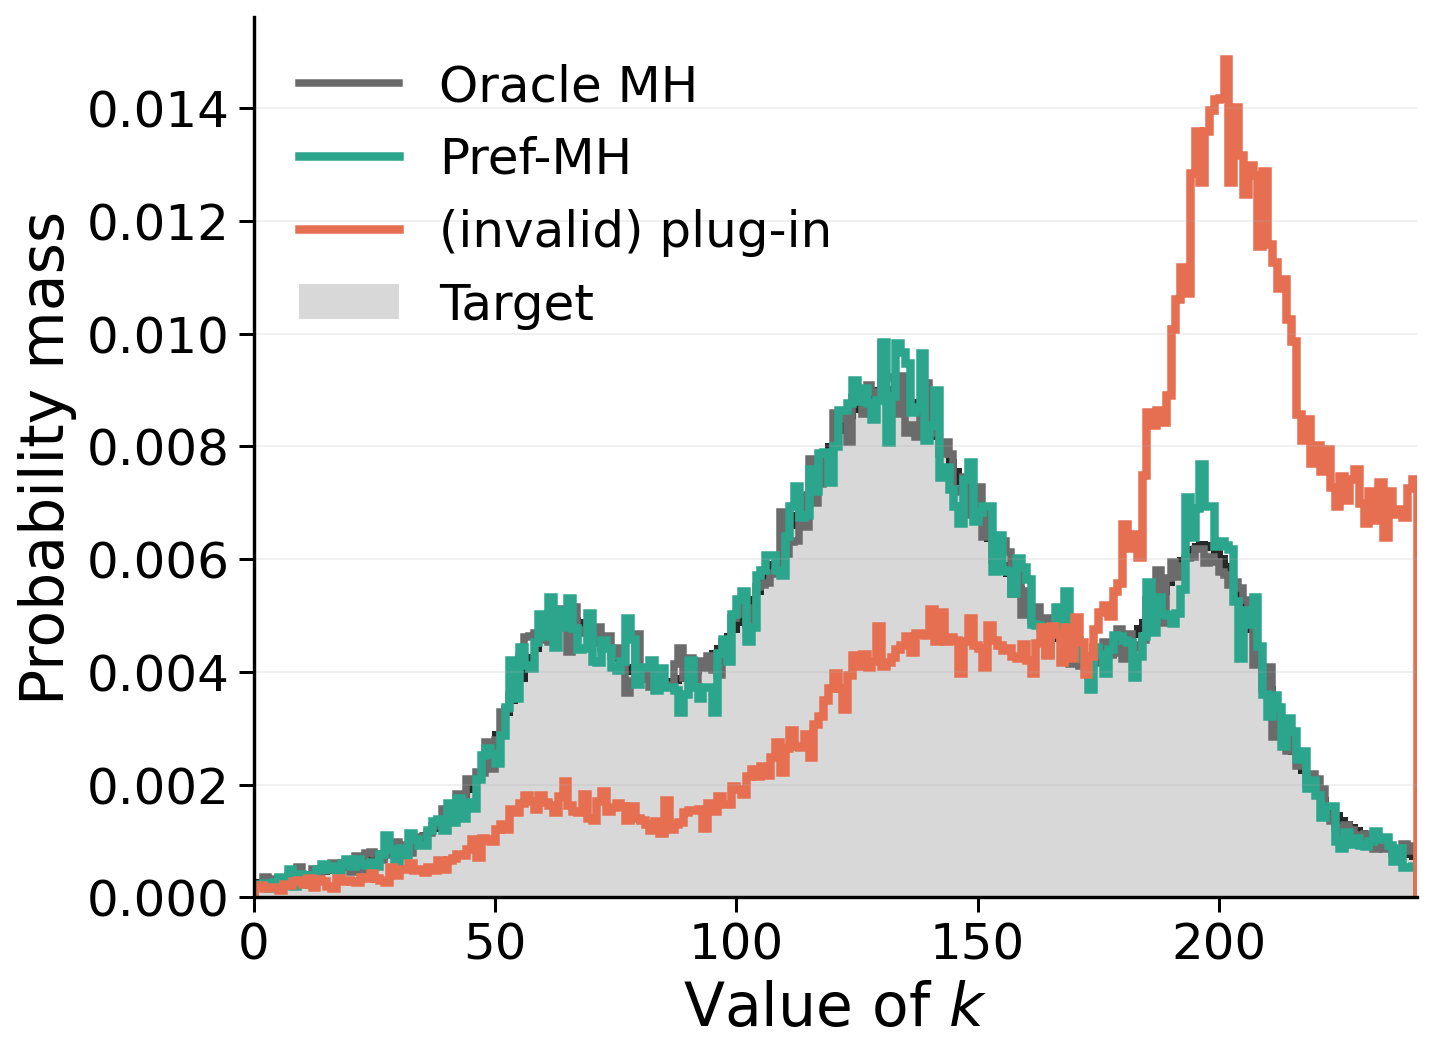

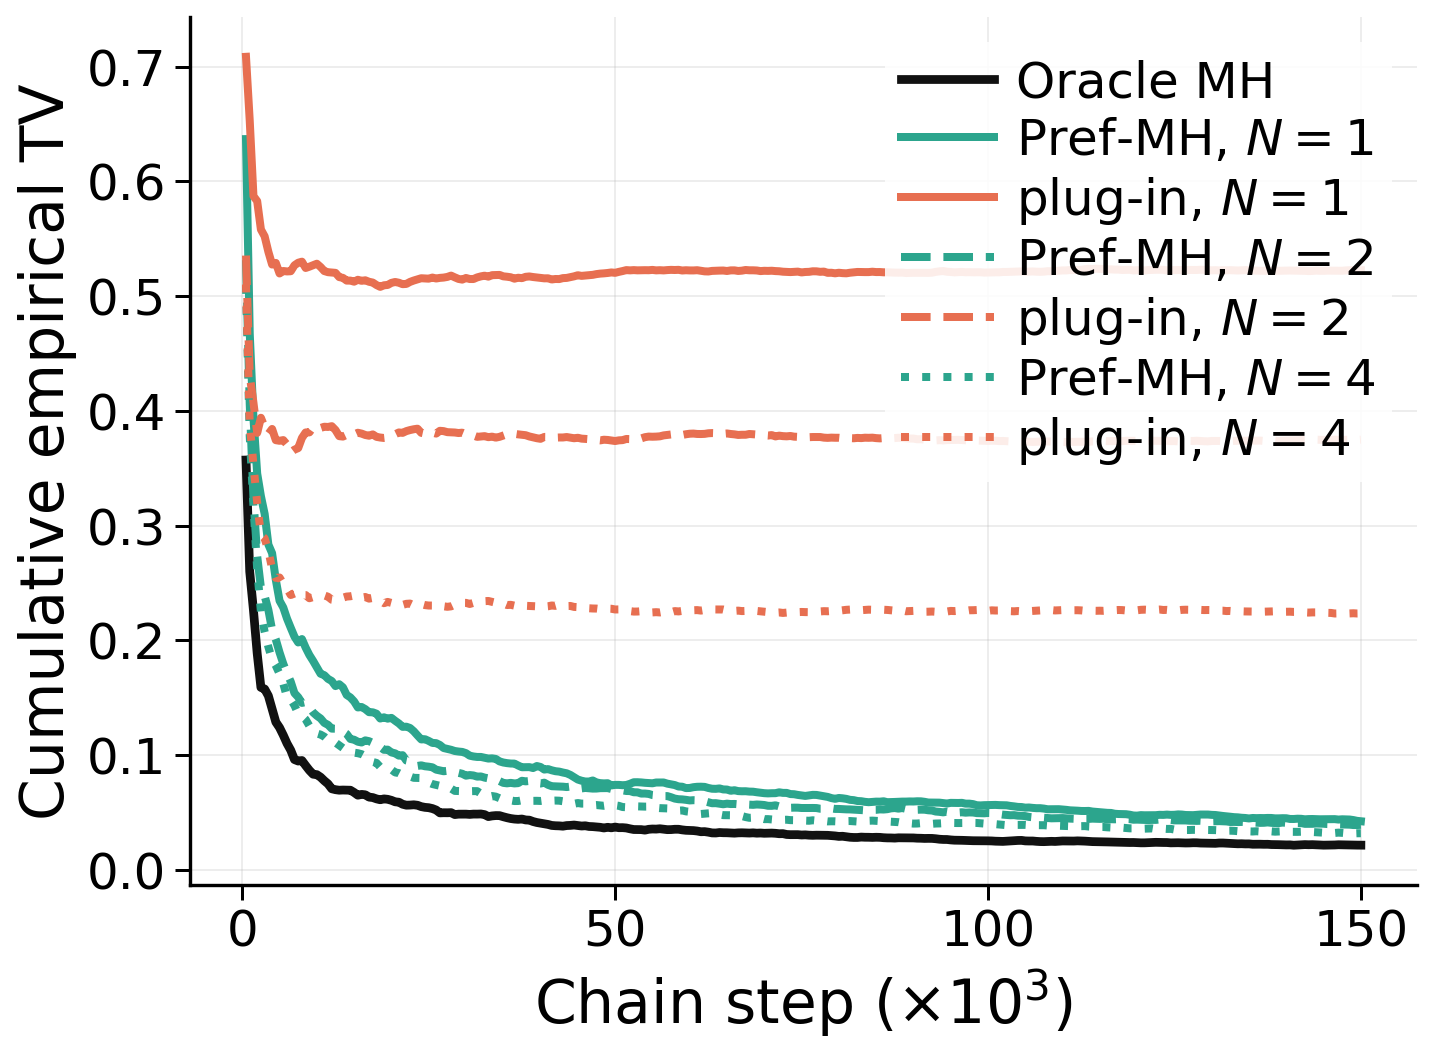


========== SUMMARY ==========
Finite state space             : k in {0, ..., 240}
Number of states               : 241
Target                         : pi(k) ∝ p0(k) exp(s(k))
Base p0(k)                    : Gaussian-shaped, center=68.0, sigma=56.0
Score s(k)                    : 0.0208 k + 0.9 G(k; 60.0, 13.0) + 0.7 G(k; 130.0, 21.0) + 1.0 G(k; 200.0, 13.0)
Distribution plot N            : 2
Convergence plot N values      : [1, 2, 4]
Chain steps                    : 150000
TV checkpoint frequency        : 500
Distribution thinning          : 2
Saved figures                  : True
Distribution figure path       : synthetic_distribution_n2.pdf
Convergence figure path        : synthetic_convergence_n_sweep.pdf


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plot style for paper
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 21,
    "axes.titlesize": 23,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "lines.linewidth": 3.1,
    "axes.linewidth": 1.35,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ============================================================
# Main knobs
# ============================================================

K_MAX = 240
STATE_SPACE = np.arange(K_MAX + 1)
n_states = len(STATE_SPACE)

N_LIST = [1, 2, 4]
N_DIST = 2

GLOBAL_PROPOSAL_PROB = 0.88

CHAIN_STEPS = 150_000
THIN = 2
TV_EVERY = 500

SAVE_FIG = True
DIST_FIG_PATH = "synthetic_distribution_n2.pdf"
CONV_FIG_PATH = "synthetic_convergence_n_sweep.pdf"

# ============================================================
# Distribution knobs
# ============================================================

BASE_CENTER_K = 68.0
BASE_SIGMA_K = 56.0

LINEAR_SLOPE_K = 6.4 / K_MAX
LINEAR_SLOPE_K = 5.0 / K_MAX

BUMP_STRENGTH = 1.0

BUMP_1_WEIGHT = 0.9
BUMP_1_CENTER_K = 56.0
BUMP_1_SIGMA_K = 13.0
BUMP_1_CENTER_K = 60.0

BUMP_2_WEIGHT = 0.7
BUMP_2_CENTER_K = 131.0
BUMP_2_SIGMA_K = 21.0
BUMP_2_CENTER_K = 130.0

BUMP_3_WEIGHT = 1.0
BUMP_3_CENTER_K = 199.0
BUMP_3_SIGMA_K = 13.0
BUMP_3_CENTER_K = 200.0

# ============================================================
# Utilities
# ============================================================

def normalize(v):
    v = np.asarray(v, dtype=float)
    s = v.sum()

    if s <= 0:
        raise ValueError("Cannot normalize vector with non-positive sum.")

    return v / s


def tv_distance(p, q):
    return 0.5 * np.abs(p - q).sum()


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)

    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))

    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)

    if out.ndim == 0:
        return float(out)

    return out


def empirical_distribution_from_chain(chain, thin=THIN):
    samples = chain[::thin]
    counts = np.bincount(samples, minlength=n_states).astype(float)
    return normalize(counts)


def cumulative_empirical_tv(chain, target_pi, every=TV_EVERY):
    checkpoints = []
    tvs = []

    counts = np.zeros(n_states, dtype=float)
    total = 0

    for t in range(1, len(chain)):
        counts[chain[t]] += 1.0
        total += 1

        if total % every == 0:
            emp = counts / total
            checkpoints.append(t)
            tvs.append(tv_distance(emp, target_pi))

    return np.array(checkpoints), np.array(tvs)


def binned_pmf(pmf, num_bins=48):
    edges = np.linspace(0, K_MAX + 1, num_bins + 1, dtype=int)
    edges = np.unique(edges)

    masses = np.array([
        pmf[edges[i]:edges[i + 1]].sum()
        for i in range(len(edges) - 1)
    ])

    return edges, masses

# ============================================================
# Non-uniform base + preference-tilted target
# ============================================================

k = STATE_SPACE.astype(float)

log_p0 = -0.5 * ((k - BASE_CENTER_K) / BASE_SIGMA_K) ** 2
p0 = normalize(np.exp(log_p0 - log_p0.max()))

bumps = (
    BUMP_1_WEIGHT
    * np.exp(-0.5 * ((k - BUMP_1_CENTER_K) / BUMP_1_SIGMA_K) ** 2)
    +
    BUMP_2_WEIGHT
    * np.exp(-0.5 * ((k - BUMP_2_CENTER_K) / BUMP_2_SIGMA_K) ** 2)
    +
    BUMP_3_WEIGHT
    * np.exp(-0.5 * ((k - BUMP_3_CENTER_K) / BUMP_3_SIGMA_K) ** 2)
)

score = LINEAR_SLOPE_K * k + BUMP_STRENGTH * bumps

log_pi = log_p0 + score
pi_true = normalize(np.exp(log_pi - log_pi.max()))

# ============================================================
# MCMC proposal and transitions
# ============================================================

def sample_proposal(current, rng):
    if rng.random() < GLOBAL_PROPOSAL_PROB:
        return int(rng.integers(n_states))

    r = rng.random()

    if r < 0.50:
        return current

    if r < 0.75:
        proposal = current - 1
    else:
        proposal = current + 1

    if 0 <= proposal < n_states:
        return proposal

    return current


def one_step_chain(current, method, rng, N):
    proposal = sample_proposal(current, rng)

    if proposal == current:
        return current, False

    d_score = score[proposal] - score[current]
    d_log_p0 = log_p0[proposal] - log_p0[current]

    p = sigmoid(d_score)
    r0 = np.exp(np.clip(d_log_p0, -700.0, 700.0))

    if method == "oracle":
        log_ratio = d_log_p0 + d_score
        alpha = min(1.0, np.exp(np.clip(log_ratio, -700.0, 700.0)))

    elif method == "pref":
        k_votes = rng.binomial(N, p)
        finite_vote_factor = k_votes / (N - k_votes + 1.0)
        alpha = min(1.0, r0 * finite_vote_factor)

    elif method == "plugin":
        k_votes = rng.binomial(N, p)

        if k_votes == 0:
            alpha = 0.0
        elif k_votes == N:
            alpha = 1.0
        else:
            empirical_odds = k_votes / (N - k_votes)
            alpha = min(1.0, r0 * empirical_odds)

    else:
        raise ValueError(f"Unknown method: {method}")

    if rng.random() < alpha:
        return proposal, True

    return current, False


def run_chain(start, steps, method, seed, N):
    local_rng = np.random.default_rng(seed)

    chain = np.empty(steps + 1, dtype=int)
    accepts = np.zeros(steps, dtype=bool)

    current = start
    chain[0] = current

    for t in range(steps):
        current, accepted = one_step_chain(
            current=current,
            method=method,
            rng=local_rng,
            N=N,
        )

        chain[t + 1] = current
        accepts[t] = accepted

    return chain, accepts

# ============================================================
# Run chains for distribution plot, N=2
# ============================================================

start_idx = 0

print("Running chains for distribution plot...")

chain_oracle_dist, acc_oracle_dist = run_chain(
    start=start_idx,
    steps=CHAIN_STEPS,
    method="oracle",
    seed=10,
    N=N_DIST,
)

chain_pref_dist, acc_pref_dist = run_chain(
    start=start_idx,
    steps=CHAIN_STEPS,
    method="pref",
    seed=11,
    N=N_DIST,
)

chain_plugin_dist, acc_plugin_dist = run_chain(
    start=start_idx,
    steps=CHAIN_STEPS,
    method="plugin",
    seed=12,
    N=N_DIST,
)

emp_oracle_dist = empirical_distribution_from_chain(chain_oracle_dist)
emp_pref_dist = empirical_distribution_from_chain(chain_pref_dist)
emp_plugin_dist = empirical_distribution_from_chain(chain_plugin_dist)

print("Done.")

# ============================================================
# Run chains for convergence plot
# ============================================================

print("Running chains for convergence plot...")

conv_results = {}

chain_oracle, acc_oracle = run_chain(
    start=start_idx,
    steps=CHAIN_STEPS,
    method="oracle",
    seed=999,
    N=1,
)

t_oracle, tv_oracle = cumulative_empirical_tv(
    chain_oracle,
    pi_true,
    every=TV_EVERY,
)

for idx, N in enumerate(N_LIST):
    chain_pref, acc_pref = run_chain(
        start=start_idx,
        steps=CHAIN_STEPS,
        method="pref",
        seed=100 + 10 * idx + 1,
        N=N,
    )

    chain_plugin, acc_plugin = run_chain(
        start=start_idx,
        steps=CHAIN_STEPS,
        method="plugin",
        seed=100 + 10 * idx + 2,
        N=N,
    )

    t_pref, tv_pref = cumulative_empirical_tv(
        chain_pref,
        pi_true,
        every=TV_EVERY,
    )

    t_plugin, tv_plugin = cumulative_empirical_tv(
        chain_plugin,
        pi_true,
        every=TV_EVERY,
    )

    conv_results[N] = {
        "t_pref": t_pref,
        "tv_pref": tv_pref,
        "t_plugin": t_plugin,
        "tv_plugin": tv_plugin,
        "acc_pref": acc_pref.mean(),
        "acc_plugin": acc_plugin.mean(),
    }

print("Done.")

# ============================================================
# Diagnostics
# ============================================================

print("\nTV distance for distribution plot, N=2:")
print(f"  Oracle MH   : {tv_distance(emp_oracle_dist, pi_true):.6e}")
print(f"  Pref-MH     : {tv_distance(emp_pref_dist, pi_true):.6e}")
print(f"  Plug-in MH  : {tv_distance(emp_plugin_dist, pi_true):.6e}")

print("\nAcceptance rates:")
print(f"  Oracle MH   : {acc_oracle.mean():.4f}")

for N in N_LIST:
    print(
        f"  N={N:<3d} | "
        f"Pref-MH: {conv_results[N]['acc_pref']:.4f} | "
        f"Plug-in: {conv_results[N]['acc_plugin']:.4f}"
    )

# ============================================================
# Plot settings
# ============================================================

c_true = "#111111"
c_oracle = "#6B6B6B"
c_pref = "#2CA58D"
c_plugin = "#E76F51"

n_linestyles = {
    1: "-",
    2: "--",
    4: ":",
    8: "-.",
}

# ============================================================
# Figure 1: distribution plot, N=2
# ============================================================

fig_dist, ax = plt.subplots(figsize=(8.4, 6.3), dpi=180)

NUM_BINS = 241

edges, pi_true_binned = binned_pmf(pi_true, NUM_BINS)
_, oracle_binned = binned_pmf(emp_oracle_dist, NUM_BINS)
_, pref_binned = binned_pmf(emp_pref_dist, NUM_BINS)
_, plugin_binned = binned_pmf(emp_plugin_dist, NUM_BINS)

ax.bar(
    edges[:-1],
    pi_true_binned,
    width=np.diff(edges),
    align="edge",
    color=c_true,
    alpha=0.16,
    linewidth=0.0,
    label="Target",
)

ax.stairs(
    pi_true_binned,
    edges,
    color=c_true,
    linewidth=2.8,
    alpha=0.90,
)

ax.stairs(
    oracle_binned,
    edges,
    color=c_oracle,
    linewidth=3.0,
    linestyle="-",
    label="Oracle MH",
)

ax.stairs(
    pref_binned,
    edges,
    color=c_pref,
    linewidth=3.4,
    linestyle="-",
    label=r"Pref-MH",
)

ax.stairs(
    plugin_binned,
    edges,
    color=c_plugin,
    linewidth=3.4,
    linestyle="-",
    label=r"(invalid) plug-in",
)

ax.set_xlabel(r"Value of $k$")
ax.set_ylabel("Probability mass")
ax.set_xlim(0, K_MAX + 1)

ax.grid(alpha=0.18, axis="y")

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=20,
)

fig_dist.tight_layout()

if SAVE_FIG:
    fig_dist.savefig(DIST_FIG_PATH, bbox_inches="tight")

plt.show()

# ============================================================
# Figure 2: convergence plot for several N values + oracle
# ============================================================

fig_conv, ax = plt.subplots(figsize=(8.4, 6.3), dpi=180)

STEP_SCALE = 1_000.0

ax.plot(
    t_oracle / STEP_SCALE,
    tv_oracle,
    color=c_true,
    linewidth=3.5,
    linestyle="-",
    label="Oracle MH",
)

for N in N_LIST:
    linestyle = n_linestyles[N]

    ax.plot(
        conv_results[N]["t_pref"] / STEP_SCALE,
        conv_results[N]["tv_pref"],
        color=c_pref,
        linewidth=3.2,
        linestyle=linestyle,
        label=rf"Pref-MH, $N={N}$",
    )

    ax.plot(
        conv_results[N]["t_plugin"] / STEP_SCALE,
        conv_results[N]["tv_plugin"],
        color=c_plugin,
        linewidth=3.2,
        linestyle=linestyle,
        label=rf"plug-in, $N={N}$",
    )

ax.set_xlabel(r"Chain step $(\times 10^3)$")
ax.set_ylabel(r"Cumulative empirical TV")

ax.locator_params(axis="x", nbins=5)

ax.grid(alpha=0.22)

ax.legend(
    frameon=True,
    fancybox=False,
    framealpha=0.88,
    edgecolor="none",
    ncol=1,
    loc="upper right",
    fontsize=20,
    borderpad=0.32,
    labelspacing=0.20,
    handlelength=1.85,
    handletextpad=0.45,
)

fig_conv.tight_layout()

if SAVE_FIG:
    fig_conv.savefig(CONV_FIG_PATH, bbox_inches="tight")

plt.show()

# ============================================================
# Compact summary
# ============================================================

print("\n========== SUMMARY ==========")
print(f"Finite state space             : k in {{0, ..., {K_MAX}}}")
print(f"Number of states               : {n_states}")
print("Target                         : pi(k) ∝ p0(k) exp(s(k))")
print(
    "Base p0(k)                    : "
    f"Gaussian-shaped, center={BASE_CENTER_K}, sigma={BASE_SIGMA_K}"
)
print(
    "Score s(k)                    : "
    f"{LINEAR_SLOPE_K:.4f} k "
    f"+ {BUMP_1_WEIGHT} G(k; {BUMP_1_CENTER_K}, {BUMP_1_SIGMA_K}) "
    f"+ {BUMP_2_WEIGHT} G(k; {BUMP_2_CENTER_K}, {BUMP_2_SIGMA_K}) "
    f"+ {BUMP_3_WEIGHT} G(k; {BUMP_3_CENTER_K}, {BUMP_3_SIGMA_K})"
)
print(f"Distribution plot N            : {N_DIST}")
print(f"Convergence plot N values      : {N_LIST}")
print(f"Chain steps                    : {CHAIN_STEPS}")
print(f"TV checkpoint frequency        : {TV_EVERY}")
print(f"Distribution thinning          : {THIN}")
print(f"Saved figures                  : {SAVE_FIG}")
if SAVE_FIG:
    print(f"Distribution figure path       : {DIST_FIG_PATH}")
    print(f"Convergence figure path        : {CONV_FIG_PATH}")
print("=============================")